In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/safaruzzamanshovo/graduate-admission-dataset/graduate_admission1.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/safaruzzamanshovo/graduate-admission-dataset/graduate_admission1.csv')

In [3]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,GPA,Research,Chance of Admit
0,295,96,2,4.9,1.7,2.93,0,0.612
1,340,119,3,4.1,1.7,3.76,0,0.708
2,336,96,1,3.2,1.8,3.12,1,0.728
3,337,108,4,3.4,1.3,2.11,0,0.643
4,323,98,1,1.1,1.3,3.40,0,0.524


In [4]:
df.shape

(1000, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          1000 non-null   int64  
 1   TOEFL Score        1000 non-null   int64  
 2   University Rating  1000 non-null   int64  
 3   SOP                1000 non-null   float64
 4   LOR                1000 non-null   float64
 5   GPA                1000 non-null   float64
 6   Research           1000 non-null   int64  
 7   Chance of Admit    1000 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 62.6 KB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
X = df.drop(columns=['Chance of Admit'])
y = df['Chance of Admit']

In [9]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test , y_train  , y_test = train_test_split(X , y , test_size = 0.2 ,  random_state = 42)

In [14]:
X_train.shape

(800, 7)

In [15]:
X_test.shape

(200, 7)

In [16]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


In [17]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [30]:
model = Sequential()

model.add(Dense(7,activation = 'relu' , input_dim = 7))
model.add(Dense(7,activation = 'relu' ))
model.add(Dense(1 , activation = 'linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(loss = 'mean_squared_error' , optimizer = 'Adam' , metrics = ['r2_score'])

In [33]:
history = model.fit(X_train_scaled  , y_train , validation_split = 0.2 , epochs = 100)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.3084 - r2_score: -32.4670 - val_loss: 0.1956 - val_r2_score: -21.0750
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1320 - r2_score: -13.3252 - val_loss: 0.0894 - val_r2_score: -9.0856
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0674 - r2_score: -6.3125 - val_loss: 0.0584 - val_r2_score: -5.5867
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0437 - r2_score: -3.7431 - val_loss: 0.0395 - val_r2_score: -3.4554
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0303 - r2_score: -2.2839 - val_loss: 0.0283 - val_r2_score: -2.1963
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0228 - r2_score: -1.4703 - val_loss: 0.0225 - val_r2_score: -1.5404
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0187 - r2_score: -1.0263 - val_loss: 0.0189 - val_r2_score: -1.1388
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0161 - r2_score: -0.7515 - val_l

In [34]:
y_pred = model.predict(X_test_scaled)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [35]:
from sklearn.metrics import r2_score


In [36]:
r2_score(y_test , y_pred)

0.8768166296943528

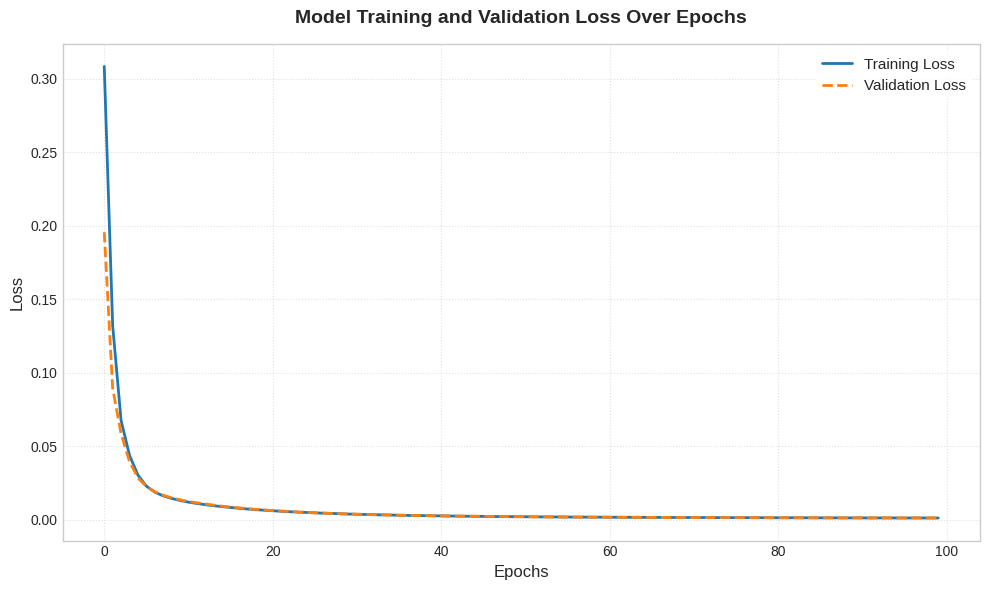

In [38]:
import matplotlib.pyplot as plt

# Set a clean plot style
plt.style.use('seaborn-v0_8-whitegrid') # Or use 'ggplot'
plt.figure(figsize=(10, 6))

# Plot train and validation loss with custom styling
plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2, linestyle='--')

# Add titles and labels with appropriate font sizes
plt.title('Model Training and Validation Loss Over Epochs', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# Customize the grid and legend
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper right', frameon=True, facecolor='white', edgecolor='none')

# Adjust layout to prevent cropping
plt.tight_layout()

# Display the plot
plt.show()


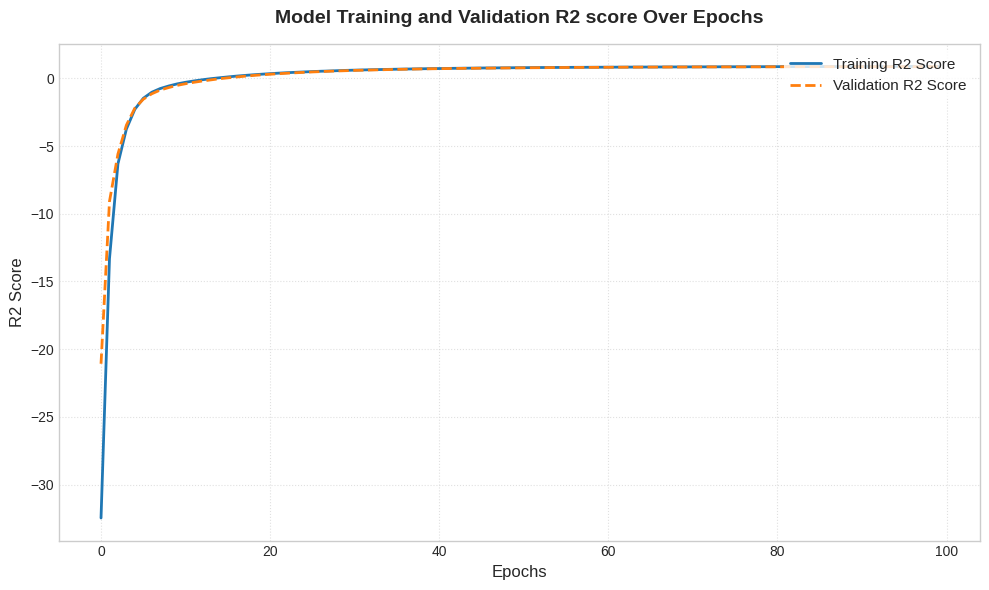

In [40]:
import matplotlib.pyplot as plt

# Set a clean plot style
plt.style.use('seaborn-v0_8-whitegrid') # Or use 'ggplot'
plt.figure(figsize=(10, 6))

# Plot train and validation loss with custom styling
plt.plot(history.history['r2_score'], label='Training R2 Score', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_r2_score'], label='Validation R2 Score', color='#ff7f0e', linewidth=2, linestyle='--')

# Add titles and labels with appropriate font sizes
plt.title('Model Training and Validation R2 score Over Epochs', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('R2 Score', fontsize=12)

# Customize the grid and legend
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper right', frameon=True, facecolor='white', edgecolor='none')

# Adjust layout to prevent cropping
plt.tight_layout()

# Display the plot
plt.show()
